# CardioVision AI — Parte 1: Pré-processamento e Organização das Imagens

**Disciplina:** Classificação de Imagens Médicas com Deep Learning

Este notebook implementa o pipeline de preparação dos dados para classificação de ECGs.

## Dataset público

Utilizamos o dataset **ECG Heartbeat Categorization Images** (Kaggle), composto por imagens de eletrocardiogramas organizadas em 4 classes:

| Classe | Descrição clínica |
|--------|-------------------|
| `normal_ecg_images` | Batimentos cardíacos normais |
| `abnormal_heartbeat_ecg_images` | Arritmias / batimentos anormais |
| `myocardial_infarction_ecg_images` | Infarto agudo do miocárdio |
| `post_mi_history_ecg_images` | Histórico pós-infarto |

> **Colab:** faça upload da pasta `data/raw/ecg_images` ou monte o Google Drive com a mesma estrutura.

In [50]:
# Descomente no Google Colab, se necessário:
# !pip install -q opencv-python-headless scikit-learn matplotlib pillow

import json
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

## 1. Configuração de caminhos

| Pasta | Função |
|-------|--------|
| `data/raw/ecg_images` | Imagens originais (entrada) |
| `data/processed/{train,validation,test}` | Imagens pré-processadas (saída) |
| `data/processed/metadata.json` | Metadados do split e hiperparâmetros |

In [51]:
RAW_PATH = Path("../data/raw/ecg_images")
PROCESSED_PATH = Path("../data/processed")
TRAIN_PATH = PROCESSED_PATH / "train"
VAL_PATH = PROCESSED_PATH / "validation"
TEST_PATH = PROCESSED_PATH / "test"
METADATA_PATH = PROCESSED_PATH / "metadata.json"

IMG_SIZE = (224, 224)          # Redimensionamento padrão para CNNs
OUTPUT_FORMAT = ".jpg"         # Conversão de formato
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
RANDOM_STATE = 42

for path in (TRAIN_PATH, VAL_PATH, TEST_PATH):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

assert RAW_PATH.exists(), (
    f"Dataset não encontrado em {RAW_PATH.resolve()}. "
    "Baixe o dataset e coloque as imagens em subpastas por classe."
)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


def list_image_files(folder: Path) -> list[Path]:
    """Lista apenas arquivos de imagem válidos dentro de uma pasta de classe."""
    return sorted(
        path
        for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def read_image_bgr(image_path: Path) -> np.ndarray:
    """Lê imagem com suporte a caminhos Unicode no Windows (cv2.imread falha com acentos)."""
    buffer = np.fromfile(str(image_path), dtype=np.uint8)
    if buffer.size == 0:
        raise ValueError(f"Arquivo vazio ou inexistente: {image_path}")

    img_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Não foi possível decodificar a imagem: {image_path}")
    return img_bgr

## 2. Exploração do dataset bruto

In [52]:
class_counts = {}
for folder in sorted(RAW_PATH.iterdir()):
    if folder.is_dir():
        images = list_image_files(folder)
        class_counts[folder.name] = len(images)
        print(f"{folder.name}: {len(images)} imagens")

total = sum(class_counts.values())
print(f"\nTotal: {total} imagens | {len(class_counts)} classes")
assert total > 0, 'Nenhuma imagem encontrada. Verifique extensões (.jpg, .png, ...).'


batimento_cardiaco_anormal: 233 imagens
historico_pos_infarto: 172 imagens
infarto_do_miocardio: 239 imagens
normal: 284 imagens

Total: 928 imagens | 4 classes


## 3. Visualização de amostras (antes do pré-processamento)

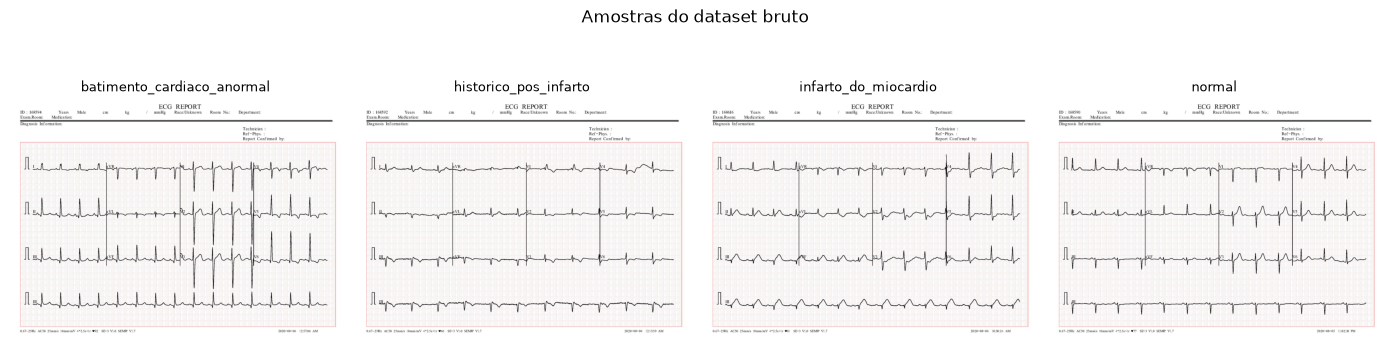

In [53]:
fig, axes = plt.subplots(1, len(class_counts), figsize=(3.5 * len(class_counts), 4))
if len(class_counts) == 1:
    axes = [axes]

for ax, class_name in zip(axes, class_counts):
    sample_path = list_image_files(RAW_PATH / class_name)[0]
    img_bgr = read_image_bgr(sample_path)
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(class_name.replace("_ecg_images", ""), fontsize=9)
    ax.axis("off")

plt.suptitle("Amostras do dataset bruto")
plt.tight_layout()
plt.show()

## 4. Pipeline de pré-processamento

Etapas aplicadas a **cada imagem**:

1. **Leitura** com OpenCV (suporta PNG, JPG, etc.)
2. **Conversão de cor** BGR → RGB (padrão para redes neurais)
3. **Redimensionamento** para 224×224 px (entrada compatível com VGG/ResNet)
4. **Normalização** dos pixels para o intervalo [0, 1] (`float32 / 255`)
5. **Conversão de formato** para JPEG (compressão uniforme)
6. **Persistência** nas pastas de treino, validação e teste

**Justificativas:**
- *224×224*: tamanho usado por modelos pré-treinados em ImageNet.
- *Normalização [0,1]*: estabiliza o gradiente e acelera a convergência.
- *Split estratificado 70/15/15*: mantém proporção de classes em todos os conjuntos.
- *Seed fixa (42)*: garante reprodutibilidade entre execuções e notebooks.

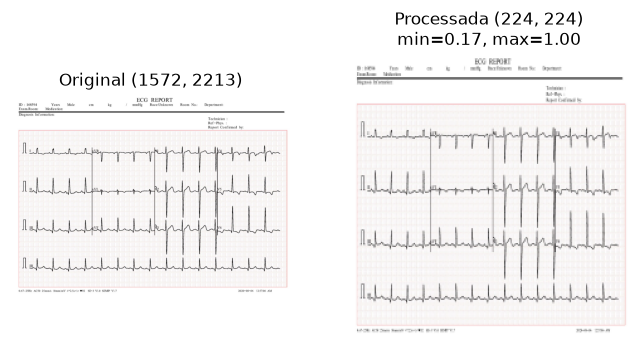

In [54]:
def preprocess_image(image_path: Path) -> np.ndarray:
    """Carrega, redimensiona e normaliza uma imagem."""
    img_bgr = read_image_bgr(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img_normalized = img_resized.astype("float32") / 255.0
    return img_normalized


def save_preprocessed_image(array: np.ndarray, destination: Path) -> None:
    """Converte array normalizado de volta para uint8 e salva em JPEG."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    img_uint8 = (np.clip(array, 0.0, 1.0) * 255).astype("uint8")
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(destination.with_suffix(OUTPUT_FORMAT)), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])


# Demonstração em uma única imagem
first_class = next(iter(class_counts))
demo_path = list_image_files(RAW_PATH / first_class)[0]
demo_original = cv2.cvtColor(read_image_bgr(demo_path), cv2.COLOR_BGR2RGB)
demo_processed = preprocess_image(demo_path)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(demo_original)
axes[0].set_title(f"Original {demo_original.shape[:2]}")
axes[0].axis("off")
axes[1].imshow(demo_processed)
axes[1].set_title(f"Processada {demo_processed.shape[:2]}\nmin={demo_processed.min():.2f}, max={demo_processed.max():.2f}")
axes[1].axis("off")
plt.show()

## 5. Divisão estratificada e persistência

In [55]:
files, labels = [], []
for class_folder in sorted(RAW_PATH.iterdir()):
    if not class_folder.is_dir():
        continue
    for image_file in list_image_files(class_folder):
        files.append(image_file)
        labels.append(class_folder.name)

X_train, X_temp, y_train, y_temp = train_test_split(
    files,
    labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=labels,
    random_state=RANDOM_STATE,
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=relative_test_size,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"Treino:     {len(X_train)} ({len(X_train)/len(files):.1%})")
print(f"Validação:  {len(X_val)} ({len(X_val)/len(files):.1%})")
print(f"Teste:      {len(X_test)} ({len(X_test)/len(files):.1%})")

Treino:     649 (69.9%)
Validação:  139 (15.0%)
Teste:      140 (15.1%)


In [56]:
def export_split(file_paths, label_list, destination_root: Path) -> None:
    for src_path, label in zip(file_paths, label_list):
        processed = preprocess_image(src_path)
        dst = destination_root / label / f"{src_path.stem}{OUTPUT_FORMAT}"
        save_preprocessed_image(processed, dst)

export_split(X_train, y_train, TRAIN_PATH)
export_split(X_val, y_val, VAL_PATH)
export_split(X_test, y_test, TEST_PATH)

class_names = sorted(class_counts.keys())
metadata = {
    "dataset": "ECG Heartbeat Categorization Images",
    "img_size": list(IMG_SIZE),
    "output_format": OUTPUT_FORMAT,
    "normalization": "pixel / 255.0 -> [0, 1]",
    "split_ratios": {"train": TRAIN_RATIO, "validation": VAL_RATIO, "test": TEST_RATIO},
    "random_state": RANDOM_STATE,
    "class_names": class_names,
    "counts": {
        "raw": class_counts,
        "train": len(X_train),
        "validation": len(X_val),
        "test": len(X_test),
    },
}

METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
METADATA_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Metadados salvos em {METADATA_PATH.resolve()}")

Metadados salvos em C:\Work\cardiovision-ai\data\processed\metadata.json


## 6. Resumo do pipeline

In [57]:
print("=== Pipeline concluído ===")
for split_name, split_path in [("Treino", TRAIN_PATH), ("Validação", VAL_PATH), ("Teste", TEST_PATH)]:
    print(f"\n{split_name}: {split_path}")
    for class_name in class_names:
        n = len(list((split_path / class_name).glob(f"*{OUTPUT_FORMAT}")))
        print(f"  {class_name}: {n} imagens")

print("\nPróximo passo: executar os notebooks 02 (CNN) e 03 (ResNet50).")

=== Pipeline concluído ===

Treino: ..\data\processed\train
  batimento_cardiaco_anormal: 163 imagens
  historico_pos_infarto: 120 imagens
  infarto_do_miocardio: 167 imagens
  normal: 199 imagens

Validação: ..\data\processed\validation
  batimento_cardiaco_anormal: 35 imagens
  historico_pos_infarto: 26 imagens
  infarto_do_miocardio: 36 imagens
  normal: 42 imagens

Teste: ..\data\processed\test
  batimento_cardiaco_anormal: 35 imagens
  historico_pos_infarto: 26 imagens
  infarto_do_miocardio: 36 imagens
  normal: 43 imagens

Próximo passo: executar os notebooks 02 (CNN) e 03 (ResNet50).
